<a href="https://colab.research.google.com/github/sohanchelekar276/MRT-IP-Assignment-4/blob/main/MRT_Assignment_4_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Helper function to show img and mount drive


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# This makes the plots look bigger and nicer
plt.rcParams['figure.figsize'] = [16, 8]

def show_img(img, title="Image", cmap_type='gray'):
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

Mounted at /content/drive


Analysing the cone features

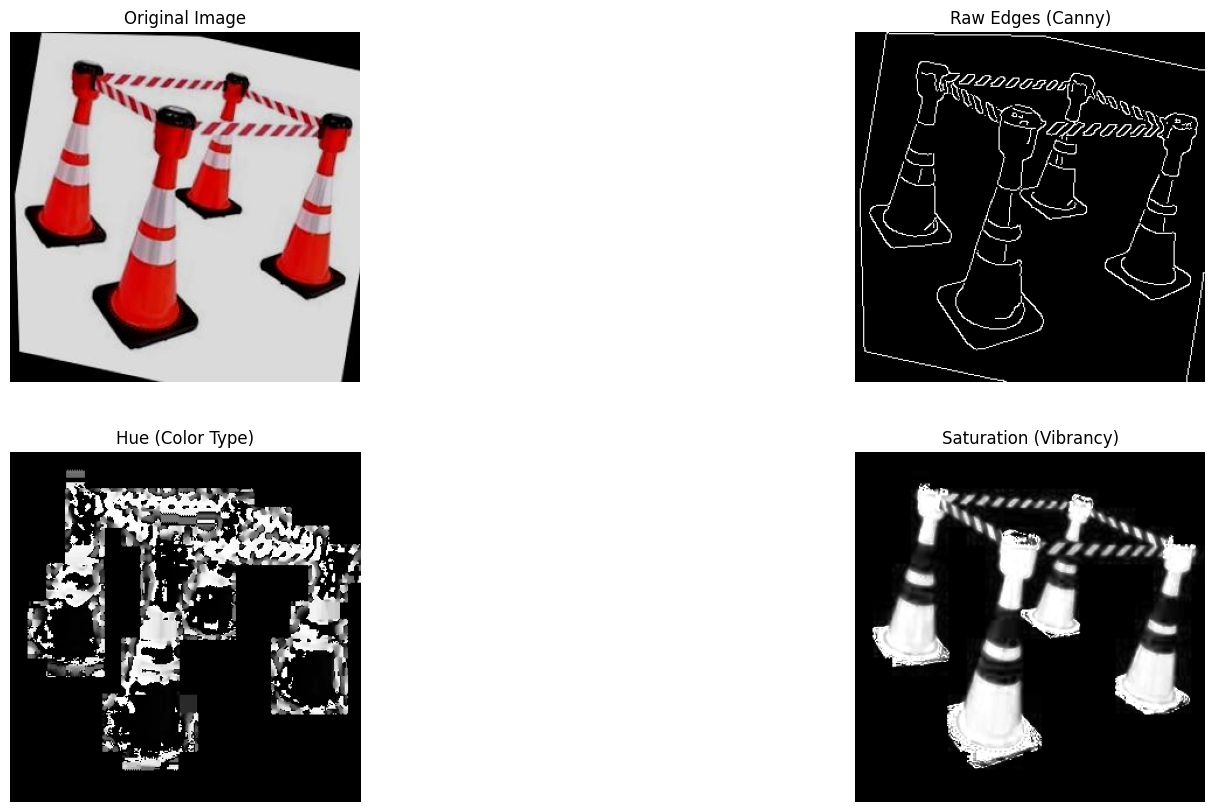

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
coneimagesgiven = '/content/drive/MyDrive/Inductions\'26/Assignment 4 - Classical CV/Cone_images/26_jpg.rf.08e1c40217a2ceae482f22e3c4ddfe60.jpg'

def analyze_cone_features(image_path):
    # 1. Load Image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load {image_path}")
        return

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Color Analysis (HSV)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # 3. Edge Analysis (Canny)
    # We blur first to reduce noise (standard practice)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Wide thresholds for Canny to see "everything"
    edges_raw = cv2.Canny(blurred, 30, 80)

    # 4. Visualize
    plt.figure(figsize=(20, 10))

    plt.subplot(2, 2, 1); plt.imshow(rgb); plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 2, 2); plt.imshow(edges_raw, cmap='gray'); plt.title("Raw Edges (Canny)")
    plt.axis('off')

    plt.subplot(2, 2, 3); plt.imshow(h, cmap='gray'); plt.title("Hue (Color Type)")
    plt.axis('off')

    plt.subplot(2, 2, 4); plt.imshow(s, cmap='gray'); plt.title("Saturation (Vibrancy)")
    plt.axis('off')

    plt.show()

analyze_cone_features(coneimagesgiven)

Colour segmentation

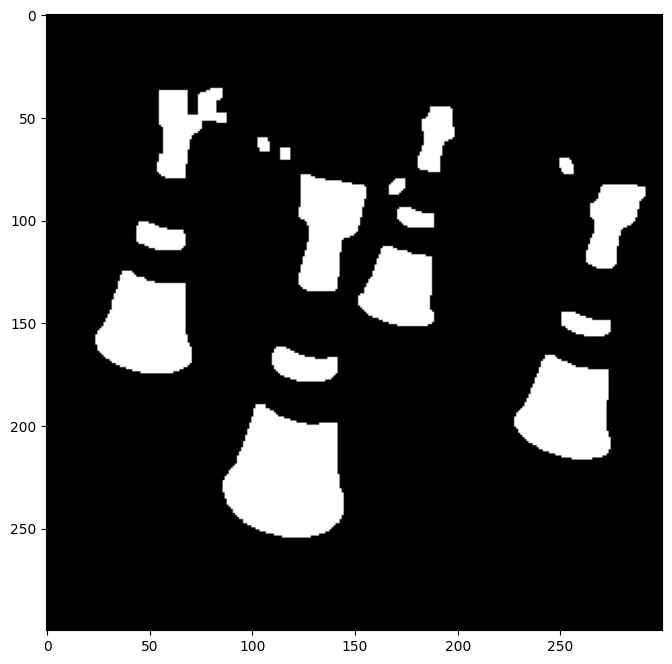

In [ ]:
def get_cone_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Color ranges for orange
    # Range 1: Red-Orange (0 to 15)
    lower_red1 = np.array([0, 100, 100]) # Saturation/Value > 100 ensures we don't pick up grey road
    upper_red1 = np.array([15, 255, 255])

    # Range 2: Red-Purple (160 to 180)
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])

    # Create masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    # Combine them
    combined_mask = cv2.bitwise_or(mask1, mask2)

    # Clean up noise
    kernel = np.ones((5,5), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)

    return combined_mask

# Test it
img = cv2.imread(coneimagesgiven)
mask = get_cone_mask(img)
plt.imshow(mask, cmap='gray'); plt.show()

Geomtetric Detection using Aspect Ratio

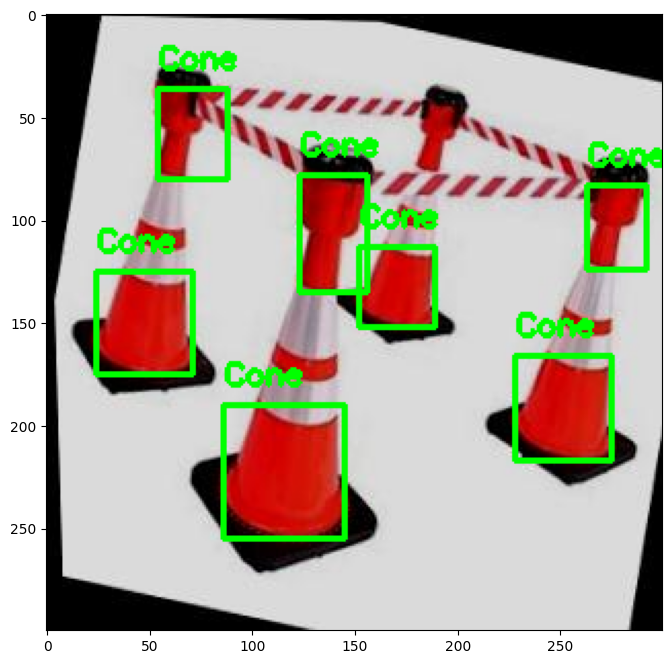

In [ ]:
def detect_cones_by_geometry(image_path):
    img = cv2.imread(image_path)
    mask = get_cone_mask(img) # Uses the function from Step 2

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = img.copy()

    for cnt in contours:
        # GEOMETRIC FILTER

        # 1. Area Filter
        area = cv2.contourArea(cnt)
        if area < 500: continue

        # 2. Bounding Box & Aspect Ratio
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(h) / w

        # Cones are usually taller than wide (Ratio > 1.0)
        if aspect_ratio > 0.8 and aspect_ratio < 4.0:

            # DRAWING
            # Green Box = Confirmed Cone
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(output, "Cone", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.show()
detect_cones_by_geometry(coneimagesgiven)

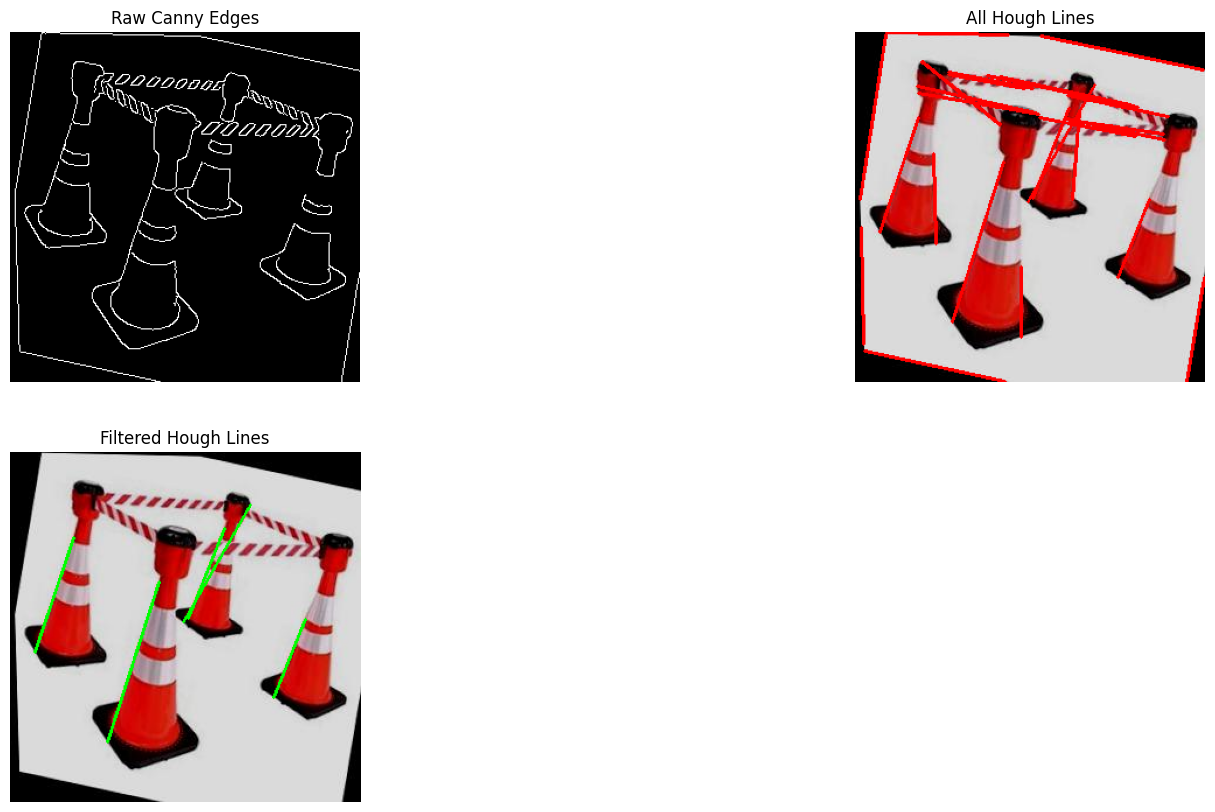

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def edge_based_cone_detector(image_path):
  #Loading and Grayscaling
  img = cv2.imread(image_path)
  if img is None:
    print(f"Error loading {image_path}")
    return

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  #Preprocessing: Bilateral Filter, blurring the grass but keeping the cone edges intact
  blurred = cv2.bilateralFilter(gray, 9, 75, 75)
  #blurred = cv2.GaussianBlur(gray, (5, 5), 0)

  #Canny Edge Detection
  high_thresh, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  low_thresh = 0.5 * high_thresh
  edges = cv2.Canny(blurred,low_thresh,high_thresh)

  #Find the contours
  contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  #Combine in a list of points
  all_points = np.vstack(contours)
  '''hull = cv2.convexHull(all_points)
  cv2.drawContours(img, [hull], -1, (0, 255, 0), 2)

  # ... (Combine contours into 'all_points' like above) ...

  # Fit the smallest possible triangle around these points
  retval, triangle = cv2.minEnclosingTriangle(all_points)

  # 'triangle' is now a set of 3 coordinates [Tip, BottomLeft, BottomRight]
  # You can draw lines between these 3 points to get your perfect cone shape.
  cv2.polylines(blurred, [np.int32(triangle)], True, (0, 255, 0), 2)'''

  #Hough Line Transform
  lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40, minLineLength=60, maxLineGap=20)

  output_all_lines = img.copy()
  output_filtered_lines = img.copy()

  if lines is not None:
    for line in lines:
      x1, y1, x2, y2 = line[0]

      #Calculate angle(in degrees)
      angle_rad = np.arctan2(y2 - y1, x2 - x1)
      angle_deg = np.degrees(angle_rad)
      angle_deg = abs(angle_deg)

      #Draw all detected lines on one image
      cv2.line(output_all_lines, (x1, y1), (x2, y2), (0,0,255), 2)

      #Cones have slanted edges so maybe between 45 and 80 degrees
      if 45 <= angle_deg <= 80:
        #Draw green cone like lines
        cv2.line(output_filtered_lines, (x1, y1), (x2,y2), (0,255,0), 2)

  #Visualisation part
  plt.figure(figsize=(20, 10))

  plt.subplot(2,2,1)
  plt.imshow(edges, cmap='gray')
  plt.title('Raw Canny Edges')
  plt.axis('off')

  plt.subplot(2,2,2)
  plt.imshow(cv2.cvtColor(output_all_lines, cv2.COLOR_BGR2RGB))
  plt.title('All Hough Lines')
  plt.axis('off')

  plt.subplot(2,2,3)
  plt.imshow(cv2.cvtColor(output_filtered_lines, cv2.COLOR_BGR2RGB))
  plt.title('Filtered Hough Lines')
  plt.axis('off')

  plt.show()

edge_based_cone_detector(coneimagesgiven)